# Beginner's Guide to Causal Discovery

This guide is for anyone who wants to understand what causal discovery is, why it matters, and how to use the `causal-ts` library — without needing a background in statistics or machine learning.

**What you will learn:**
1. The difference between correlation and causation, and why it matters
2. The four ways two variables can appear statistically related
3. What causal discovery is and how it differs from causal inference
4. The assumptions that make discovery from data possible
5. The two main families of discovery algorithms and their trade-offs
6. How nonstationarity creates spurious correlations — and how `causal-ts` handles it

---

> **Prerequisites:** Basic Python, NumPy, and Pandas. No statistics background needed.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import networkx as nx
from sklearn.linear_model import LinearRegression

from causalts.synthetic_data.synthetic_datasets import ex2, ex1_nonstationary, confounded_trends
from causalts.baselines import ges_discovery
from causalts import run_cdnots, make_c_array
from causalts.ci_tests import PartialCorr
from causalts.plotting import plot_graph, compare_graphs, corrplot
from causalts.utils import evaluate_graph

rng = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 100

---

## The Ladder of Causation

Judea Pearl, one of the founders of modern causal inference, describes three levels of causal reasoning. Most data science lives only at the first level — but causal discovery lets us climb higher.

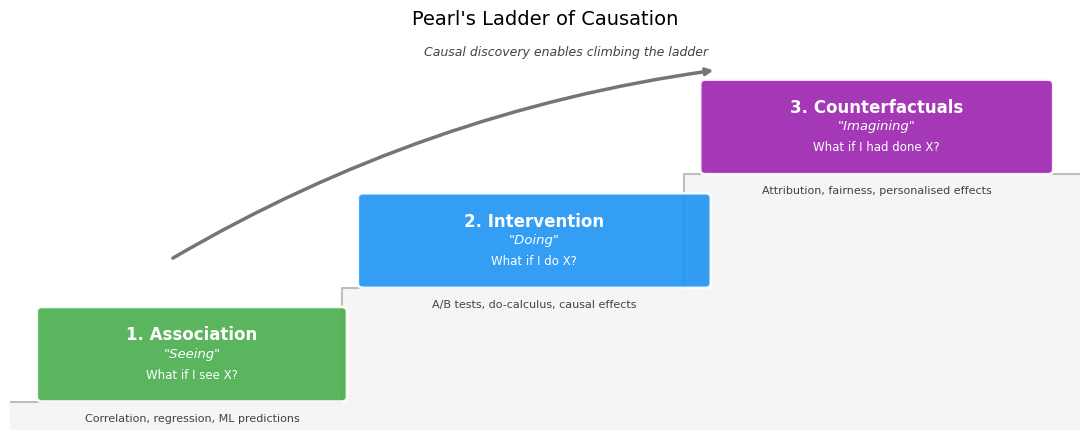

In [2]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.set_xlim(0, 10)
ax.set_ylim(-0.3, 3.8)
ax.axis("off")

levels = [
    dict(x=0.3,  y=0.0, w=2.8, h=1.0, color="#4caf50",
         title="1. Association",   subtitle="Seeing",
         q="What if I see X?",
         eg="Correlation, regression, ML predictions"),
    dict(x=3.3,  y=1.2, w=3.2, h=1.0, color="#2196f3",
         title="2. Intervention",  subtitle="Doing",
         q="What if I do X?",
         eg="A/B tests, do-calculus, causal effects"),
    dict(x=6.5,  y=2.4, w=3.2, h=1.0, color="#9c27b0",
         title="3. Counterfactuals", subtitle="Imagining",
         q="What if I had done X?",
         eg="Attribution, fairness, personalised effects"),
]

# Draw staircase background
stair_x = [0.0, 3.1, 3.1, 6.3, 6.3, 10.0, 10.0, 0.0]
stair_y = [0.0, 0.0, 1.2, 1.2, 2.4,  2.4,  -0.3, -0.3]
ax.fill(stair_x, stair_y, color="#f5f5f5", zorder=0)
ax.plot(stair_x[:-2], stair_y[:-2], color="#bdbdbd", lw=1.5, zorder=1)

for lv in levels:
    rect = mpatches.FancyBboxPatch(
        (lv["x"], lv["y"]+0.05), lv["w"], lv["h"]-0.1,
        boxstyle="round,pad=0.05", facecolor=lv["color"],
        edgecolor="white", linewidth=2, zorder=2, alpha=0.92)
    ax.add_patch(rect)
    cx = lv["x"] + lv["w"] / 2
    cy = lv["y"] + lv["h"] / 2
    ax.text(cx, cy + 0.20, lv["title"],   ha="center", va="center",
            fontsize=12, fontweight="bold", color="white", zorder=3)
    ax.text(cx, cy + 0.00, '"' + lv["subtitle"] + '"', ha="center", va="center",
            fontsize=9.5, color="white", style="italic", zorder=3)
    ax.text(cx, cy - 0.22, lv["q"],       ha="center", va="center",
            fontsize=8.5, color="white", zorder=3)

    ax.text(cx, lv["y"] - 0.18, lv["eg"], ha="center", va="center",
            fontsize=8, color="#424242", zorder=3)

# Arrow showing climb
ax.annotate("", xy=(6.6, 3.5), xytext=(1.5, 1.5),
            arrowprops=dict(arrowstyle="->", color="#757575",
                            lw=2.5, connectionstyle="arc3,rad=-0.1"))
ax.text(5.2, 3.65, "Causal discovery enables climbing the ladder",
        ha="center", fontsize=9, color="#424242", style="italic")

ax.set_title("Pearl's Ladder of Causation", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

Standard machine learning — correlations, predictions, recommendations — lives entirely at **Level 1**. To answer questions like *"would sales increase if we raised the price?"* or *"did this drug cause the recovery?"*, you need to climb to **Level 2**. That requires a causal graph. **Causal discovery** is the process of learning that graph from data.

---

## Part 1 — What Is Causality?

### 1.1 When Correlation Misleads

Consider two asset prices that move together closely over a short window. A naive analyst concludes they are causally linked. But zoom out — and the relationship falls apart.

Below we simulate exactly this: two series driven by a common hidden trend that reverses midway through the sample. In the first half they look tightly correlated; in the second half they diverge completely.

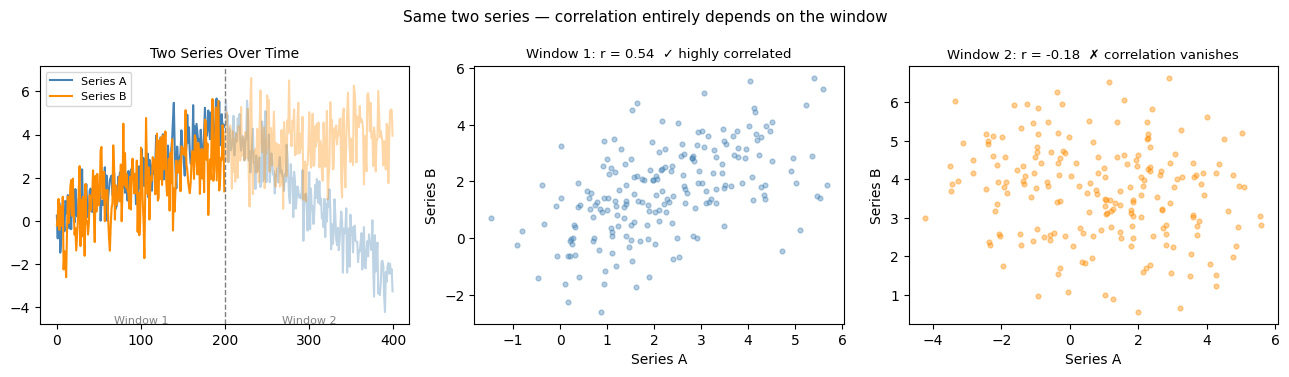

Full-sample correlation: -0.08
Both series share a common hidden driver — neither causes the other.


In [3]:
T = 400
t = np.arange(T)

# Hidden driver: rises then falls
driver = np.concatenate([np.linspace(0, 5, T//2), np.linspace(5, -3, T//2)])

series_A = 0.9 * driver + 0.8 * rng.standard_normal(T)   # follows driver closely
series_B = 0.7 * driver + 1.2 * rng.standard_normal(T)   # also follows driver
# After midpoint, B reverses direction (new firm-specific factor)
series_B[T//2:] += np.linspace(0, 6, T//2)

mid = T // 2
r_first  = np.corrcoef(series_A[:mid],  series_B[:mid])[0, 1]
r_second = np.corrcoef(series_A[mid:],  series_B[mid:])[0, 1]
r_full   = np.corrcoef(series_A, series_B)[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# Time series plot
axes[0].plot(t[:mid],  series_A[:mid],  color="steelblue",  lw=1.5, label="Series A")
axes[0].plot(t[:mid],  series_B[:mid],  color="darkorange", lw=1.5, label="Series B")
axes[0].plot(t[mid:],  series_A[mid:],  color="steelblue",  lw=1.5, alpha=0.35)
axes[0].plot(t[mid:],  series_B[mid:],  color="darkorange", lw=1.5, alpha=0.35)
axes[0].axvline(mid, color="gray", lw=1, ls="--")
axes[0].text(mid//2,   axes[0].get_ylim()[0], "Window 1", ha="center", fontsize=8, color="gray")
axes[0].text(mid*1.5,  axes[0].get_ylim()[0], "Window 2", ha="center", fontsize=8, color="gray")
axes[0].legend(fontsize=8)
axes[0].set_title("Two Series Over Time", fontsize=10)

# Scatter: first window
axes[1].scatter(series_A[:mid], series_B[:mid], alpha=0.4, s=12, color="steelblue")
axes[1].set_xlabel("Series A"); axes[1].set_ylabel("Series B")
axes[1].set_title(f"Window 1: r = {r_first:.2f}  ✓ highly correlated", fontsize=9.5)

# Scatter: second window
axes[2].scatter(series_A[mid:], series_B[mid:], alpha=0.4, s=12, color="darkorange")
axes[2].set_xlabel("Series A"); axes[2].set_ylabel("Series B")
axes[2].set_title(f"Window 2: r = {r_second:.2f}  ✗ correlation vanishes", fontsize=9.5)

fig.suptitle("Same two series — correlation entirely depends on the window",
             fontsize=11)
plt.tight_layout()
plt.show()
print(f"Full-sample correlation: {r_full:.2f}")
print("Both series share a common hidden driver — neither causes the other.")

This is not a pathological case — it is the norm in financial and economic data, where multiple variables respond to the same macro environment. A causal discovery algorithm would find the *common driver*, not a spurious direct link between A and B.

### 1.2 The Four Sources of Statistical Dependence

Any time two variables X and Y are statistically related, one of four things is happening:

| # | Source | Description | Example |
|---|---|---|---|
| 1 | **Random fluctuation** | With small samples, any two variables can appear correlated by chance | Tossing two coins 10 times |
| 2 | **Direct causation** | X directly affects Y | Smoking → Lung cancer |
| 3 | **Common cause (Fork)** | A third variable Z causes both X and Y | Summer Heat -> Ice Cream Consumption & Shark related deaths|
| 4 | **Collider conditioning** | X and Y both cause Z; we accidentally condition on Z | Exercise → Health ← Diet |

Understanding which of these is operating requires **causal reasoning**, not just statistics.

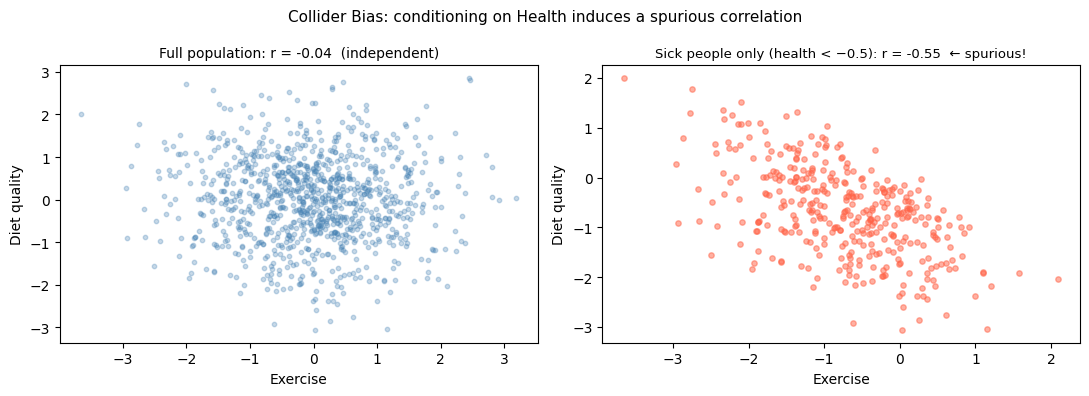

In [4]:
# Collider bias: Exercise and Diet are independent — until we look only at sick people
n = 1000
exercise = rng.standard_normal(n)
diet     = rng.standard_normal(n)
health   = exercise + diet + 0.5 * rng.standard_normal(n)  # collider

mask = health < -0.5   # "sick" sub-population
r_uncond = np.corrcoef(exercise, diet)[0, 1]
r_cond   = np.corrcoef(exercise[mask], diet[mask])[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(exercise, diet, alpha=0.3, s=10, color="steelblue")
axes[0].set_title(f"Full population: r = {r_uncond:.2f}  (independent)", fontsize=10)
axes[0].set_xlabel("Exercise"); axes[0].set_ylabel("Diet quality")

axes[1].scatter(exercise[mask], diet[mask], alpha=0.5, s=15, color="tomato")
axes[1].set_title(f"Sick people only (health < −0.5): r = {r_cond:.2f}  ← spurious!",
                  fontsize=9.5)
axes[1].set_xlabel("Exercise"); axes[1].set_ylabel("Diet quality")

fig.suptitle("Collider Bias: conditioning on Health induces a spurious correlation",
             fontsize=11)
plt.tight_layout()
plt.show()

**What just happened?** Exercise and Diet are completely independent. But among sick people (conditioning on Health), poor diet and lack of exercise artificially co-occur — because either one alone is enough to make you sick. This is **collider bias** (Berkson's paradox).

### 1.3 Causal Graphs (DAGs)

We represent causal relationships as a **Directed Acyclic Graph (DAG)**:
- Each **node** is a variable.
- A directed **edge** X → Y means "X directly causes Y".
- **Acyclic** means no feedback loops at any single point in time.

Three elementary structures appear in every causal analysis:

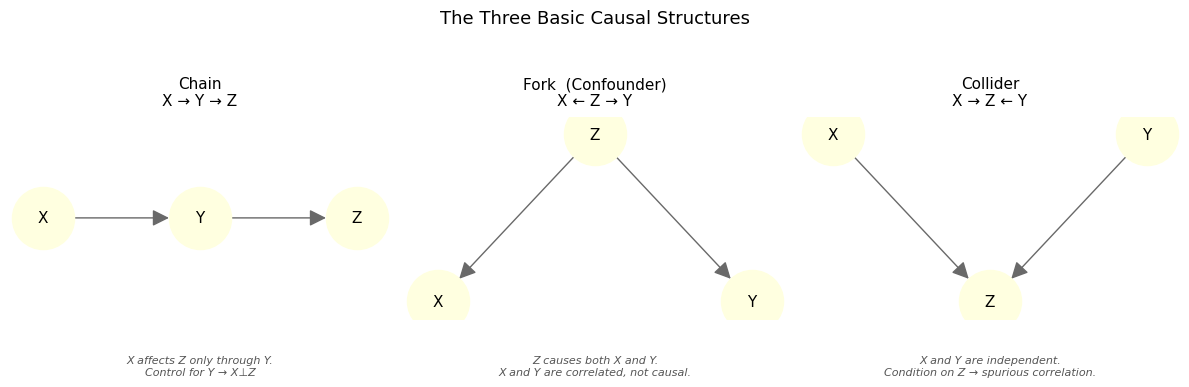

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

configs = [
    ("Chain\nX → Y → Z",
     [("X", "Y"), ("Y", "Z")],
     {"X": (0, 0), "Y": (1, 0), "Z": (2, 0)},
     "X affects Z only through Y.\nControl for Y → X⊥Z"),
    ("Fork  (Confounder)\nX ← Z → Y",
     [("Z", "X"), ("Z", "Y")],
     {"X": (0, 0), "Z": (1, 1), "Y": (2, 0)},
     "Z causes both X and Y.\nX and Y are correlated, not causal."),
    ("Collider\nX → Z ← Y",
     [("X", "Z"), ("Y", "Z")],
     {"X": (0, 1), "Y": (2, 1), "Z": (1, 0)},
     "X and Y are independent.\nCondition on Z → spurious correlation."),
]

for ax, (title, edges, pos, note) in zip(axes, configs):
    G = nx.DiGraph(edges)
    nx.draw(G, pos=pos, with_labels=True, ax=ax,
            node_color="lightyellow", node_size=2000,
            font_size=11, arrows=True, arrowsize=25,
            edge_color="dimgray", connectionstyle="arc3,rad=0.0")
    ax.set_title(title, fontsize=11, pad=8)
    ax.text(0.5, -0.18, note, transform=ax.transAxes,
            ha="center", va="top", fontsize=8, color="#555555",
            style="italic")

plt.suptitle("The Three Basic Causal Structures", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

> **💡 Why the collider is the useful one**
>
> A chain (`X → Y → Z`) and a fork (`X ← Y → Z`) leave the *same* fingerprint in the data: all three variables are associated, and there is one node — the **mediator** `Y` in the chain, the **confounder** `Y` in the fork — that makes the outer two independent once you condition on it. Nothing in the observational distribution separates the two mechanisms. They are **Markov equivalent**, and from data alone which one generated it is **unidentifiable**.
>
> The collider (`X → Y ← Z`) is the interesting case, because it runs the other way. `X` and `Z` start out *independent*, and conditioning on `Y` makes them dependent. That reversal is a signature: if two apparently unrelated variables suddenly become related once you condition on a third, that third variable must be a common **descendant** of both. It is the one local pattern whose direction can be read straight off the data — which is exactly what constraint-based algorithms exploit to orient edges, given causal sufficiency, faithfulness, and a CI test with enough power to see the difference.


### 1.4 Time Series Causal Graphs

In time series, every variable exists at multiple time steps. A causal link `X(t−2) → Y(t)` means *the value of X two periods ago causes today's Y*. Time ordering gives us a free directional constraint — causes cannot come after their effects.

The **unrolled graph** below shows the full picture: each column is a time step, each row is a variable, and arrows cross columns to show lagged effects. On the right is the compact **summary graph** that `causal-ts` produces — collapsing the time axis and labelling each arrow with its lag.

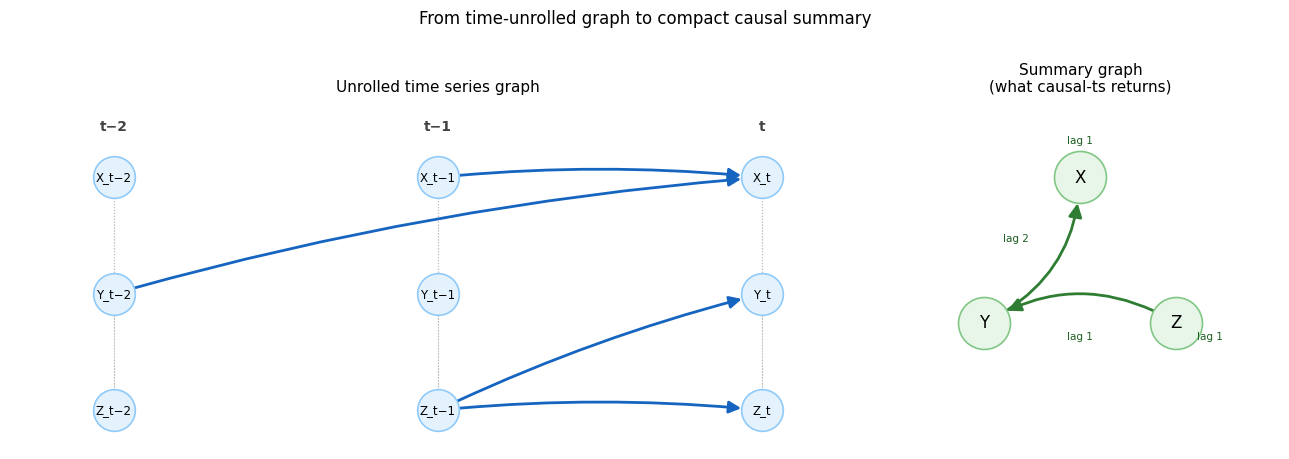

In [6]:
# Unrolled time series DAG  (inspired by slide 15 of the BBQ seminar)
# Three variables X, Y, Z over three time steps t-2, t-1, t
# True links: X(t-1)->X(t), Y(t-2)->X(t), Z(t-1)->Y(t), Z(t-1)->Z(t)

vars_   = ["X", "Y", "Z"]
lags    = ["t−2", "t−1", "t"]
n_vars, n_lags = len(vars_), len(lags)

# Node positions: (col=lag, row=var)
pos_unrolled = {}
for li, lag in enumerate(lags):
    for vi, var in enumerate(vars_):
        pos_unrolled[f"{var}_{lag}"] = (li * 2.5, -vi * 1.5)

# Edges (lagged causal links)
edges_unrolled = [
    ("X_t−1", "X_t"),     # X self-lag 1
    ("Y_t−2", "X_t"),     # Y -> X at lag 2
    ("Z_t−1", "Y_t"),     # Z -> Y at lag 1
    ("Z_t−1", "Z_t"),     # Z self-lag 1
]
# All self-connections within each time slice (contemporaneous, undirected display)
within = [(f"{v1}_{l}", f"{v2}_{l}")
          for l in lags for i, v1 in enumerate(vars_)
          for v2 in vars_[i+1:]]

# Summary graph positions (circular)
angles = np.linspace(0, 2*np.pi, n_vars, endpoint=False) + np.pi/2
pos_summary = {v: (np.cos(a), np.sin(a)) for v, a in zip(vars_, angles)}
edges_summary = [("Y", "X"), ("X", "X"), ("Z", "Y"), ("Z", "Z")]
edge_labels_summary = {("Y", "X"): "lag 2", ("X", "X"): "lag 1",
                       ("Z", "Y"): "lag 1", ("Z", "Z"): "lag 1"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5),
                         gridspec_kw={"width_ratios": [3, 1.4]})

# --- Left: unrolled ---
ax = axes[0]
G_unroll = nx.DiGraph()
G_unroll.add_nodes_from(pos_unrolled.keys())
G_unroll.add_edges_from(edges_unrolled)
G_within  = nx.Graph(within)

# Draw dotted contemporaneous edges first (background)
nx.draw_networkx_edges(G_within,  pos_unrolled, ax=ax,
                       edge_color="#bdbdbd", width=0.8, style="dotted")

# Draw nodes
nx.draw_networkx_nodes(G_unroll, pos_unrolled, ax=ax,
                       node_color="#e3f2fd", node_size=900, linewidths=1.2,
                       edgecolors="#90caf9")
nx.draw_networkx_labels(G_unroll, pos_unrolled, ax=ax, font_size=8.5)

# Draw causal arrows ON TOP of nodes — pass node_size so arrowheads clip at node boundary
nx.draw_networkx_edges(G_unroll,  pos_unrolled, ax=ax,
                       edge_color="#1565c0", width=2.0,
                       arrowsize=18, arrowstyle="-|>",
                       node_size=900,
                       connectionstyle="arc3,rad=-0.05",
                       min_source_margin=15, min_target_margin=15)

for li, lag in enumerate(lags):
    ax.text(li * 2.5, 0.6, lag, ha="center", fontsize=10,
            color="#424242", fontweight="bold")

ax.set_xlim(-0.8, 5.8)
ax.set_ylim(-3.5, 1.0)
ax.set_title("Unrolled time series graph", fontsize=11)
ax.axis("off")

# --- Right: summary graph ---
ax2 = axes[1]
G_sum = nx.MultiDiGraph()
G_sum.add_nodes_from(vars_)
G_sum.add_edges_from(edges_summary)
nx.draw_networkx_nodes(G_sum, pos_summary, ax=ax2,
                       node_color="#e8f5e9", node_size=1400, linewidths=1.2,
                       edgecolors="#81c784")
nx.draw_networkx_labels(G_sum, pos_summary, ax=ax2, font_size=12)
nx.draw_networkx_edges(G_sum, pos_summary, ax=ax2,
                       edge_color="#2e7d32", width=2.0,
                       arrowsize=20, arrowstyle="-|>",
                       node_size=1400,
                       connectionstyle="arc3,rad=0.3",
                       min_source_margin=15, min_target_margin=15)
for (u, v), label in edge_labels_summary.items():
    mx = (pos_summary[u][0] + pos_summary[v][0]) / 2
    my = (pos_summary[u][1] + pos_summary[v][1]) / 2
    ax2.text(mx * 1.35, my * 1.35, label, fontsize=7.5,
             ha="center", color="#1b5e20")
ax2.set_title("Summary graph\n(what causal-ts returns)", fontsize=11)
ax2.set_xlim(-1.8, 1.8)
ax2.set_ylim(-1.8, 1.8)
ax2.axis("off")

fig.suptitle("From time-unrolled graph to compact causal summary",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---

## Part 2 — Causal Discovery vs Causal Inference

These two terms are often confused. They refer to two different questions:

### Discovery: *What is the causal structure?*

Given data, learn **which edges exist and in which direction** — i.e., draw the causal graph.  
Output: a DAG (or CPDAG — a partially directed graph when direction cannot be uniquely determined from data alone).

Example: *Does advertising spending cause sales, or does sales performance drive the advertising budget?*

### Inference: *How strong is a specific causal effect?*

Given a causal graph (known or assumed), estimate the **magnitude of an effect** — as if we had run a controlled experiment.  
Output: a number — e.g. "increasing X by 1 unit increases Y by 0.4 on average".

Example: *By how much would sales increase if we raised advertising budget by 10%?*

### How they connect

In practice, discovery and inference form a **two-step pipeline**:

```
Observational data  →  [Discovery]  →  Causal graph  →  [Inference]  →  Effect estimate
```

If you already have a trusted causal graph (from domain knowledge or an experiment), you can skip straight to inference. If you don't, run discovery first.

**`causal-ts` focuses on the discovery step** — for time series with nonstationarity. The companion notebook [`effect_estimation.ipynb`](effect_estimation.ipynb) covers the inference step using DoWhy.

> ⚠️ A poor graph leads to wrong effect estimates. Discovery quality matters.

---

## Part 3 — When Can We Trust Observational Data?

Discovery from observational data is only possible under three assumptions. Violating any of them silently leads to wrong graphs.

### The Three Core Assumptions

**1. Causal Markov Condition** — Each variable is independent of its non-descendants given its direct parents. The graph encodes all conditional independence relationships in the data.

**2. Faithfulness** — Every conditional independence in the data corresponds to a graph separation. No accidental independences from cancelling paths.

**3. Causal Sufficiency** — No hidden common causes between observed variables. If a hidden Z causes both X and Y, the algorithm will wrongly place a direct X → Y edge.

### How Do CI Tests Work? (The Engine of Constraint-Based Discovery)

Constraint-based methods rely on **conditional independence (CI) tests**: statistical tests that check whether X is independent of Y given a set of conditioning variables Z.

The linear version (partial correlation) works like this: regress both X and Y on Z, then check whether the *residuals* are correlated. If they are not — X and Y are conditionally independent given Z, and the X–Y edge can be removed.

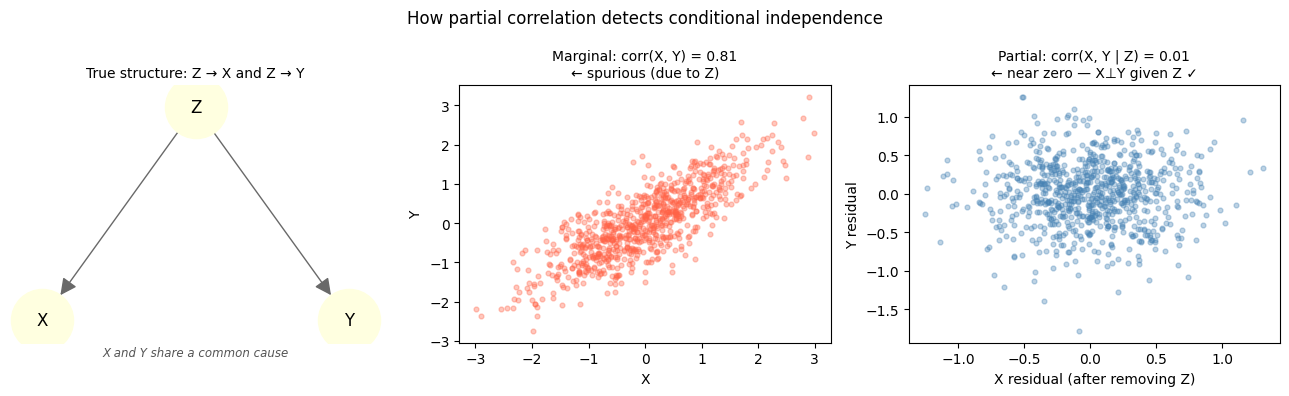

Conclusion: X and Y are NOT directly connected — the CI test correctly removes this edge.


In [7]:
# Visual: what conditional independence testing does
# True structure: Z -> X  and  Z -> Y  (fork — X and Y share common cause Z)
# X and Y are correlated marginally, but independent given Z.

n = 800
Z = rng.standard_normal(n)
X = 0.9 * Z + 0.4 * rng.standard_normal(n)   # Z causes X
Y = 0.8 * Z + 0.4 * rng.standard_normal(n)   # Z causes Y  (not X!)

# Raw correlation
r_raw = np.corrcoef(X, Y)[0, 1]

# Partial correlation: residuals after regressing on Z
res_X = X - LinearRegression().fit(Z.reshape(-1,1), X).predict(Z.reshape(-1,1))
res_Y = Y - LinearRegression().fit(Z.reshape(-1,1), Y).predict(Z.reshape(-1,1))
r_partial = np.corrcoef(res_X, res_Y)[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# True graph
ax0 = axes[0]
G_fork = nx.DiGraph([("Z", "X"), ("Z", "Y")])
pos_fork = {"Z": (1, 1), "X": (0, 0), "Y": (2, 0)}
nx.draw(G_fork, pos=pos_fork, ax=ax0, with_labels=True,
        node_color="lightyellow", node_size=2000, font_size=12,
        arrows=True, arrowsize=25, edge_color="dimgray")
ax0.set_title("True structure: Z → X and Z → Y", fontsize=10)
ax0.text(0.5, -0.05, "X and Y share a common cause",
         transform=ax0.transAxes, ha="center", fontsize=8.5,
         color="#555", style="italic")

# Raw scatter X vs Y
axes[1].scatter(X, Y, alpha=0.35, s=12, color="tomato")
axes[1].set_xlabel("X"); axes[1].set_ylabel("Y")
axes[1].set_title(f"Marginal: corr(X, Y) = {r_raw:.2f}\n← spurious (due to Z)",
                  fontsize=10)

# Residual scatter
axes[2].scatter(res_X, res_Y, alpha=0.35, s=12, color="steelblue")
axes[2].set_xlabel("X residual (after removing Z)"); axes[2].set_ylabel("Y residual")
axes[2].set_title(f"Partial: corr(X, Y | Z) = {r_partial:.2f}\n← near zero — X⊥Y given Z ✓",
                  fontsize=10)

fig.suptitle("How partial correlation detects conditional independence",
             fontsize=12)
plt.tight_layout()
plt.show()
print("Conclusion: X and Y are NOT directly connected — the CI test correctly removes this edge.")

This is exactly how constraint-based algorithms work: they systematically test pairs of variables, conditioning on increasingly large sets, and delete edges when conditional independence is found.

### Faithfulness Failure

One thing that can go wrong: if two paths between X and Z have coefficients that cancel, the CI test sees near-zero correlation and deletes the edge — even though X truly causes Z.

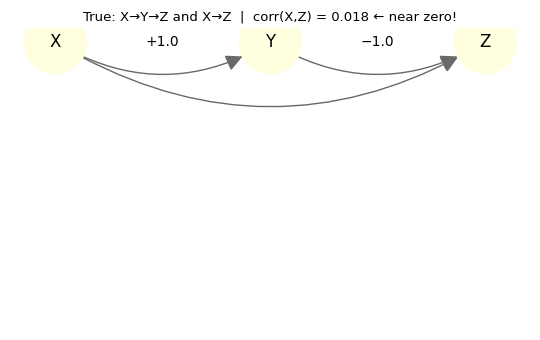

X→Z path (+1) and X→Y→Z path (−1) cancel: a CI test wrongly removes X→Z.


In [8]:
# Faithfulness failure: X -> Y -> Z (coeff -1) and X -> Z directly (coeff +1) cancel
T = 2000
X_ = rng.standard_normal(T)
Y_ = 1.0 * X_ + 0.1 * rng.standard_normal(T)
Z_ = -1.0 * Y_ + 1.0 * X_ + 0.1 * rng.standard_normal(T)   # two paths cancel

r_xz = np.corrcoef(X_, Z_)[0, 1]

fig, ax = plt.subplots(figsize=(5.5, 3.5))
G_ = nx.DiGraph([("X", "Y"), ("Y", "Z"), ("X", "Z")])
pos_ = {"X": (0, 0), "Y": (1, 0), "Z": (2, 0)}
edge_labels_ = {("X", "Y"): "+1.0", ("Y", "Z"): "−1.0", ("X", "Z"): "+1.0"}
nx.draw(G_, pos=pos_, with_labels=True, ax=ax,
        node_color="lightyellow", node_size=2000, font_size=12,
        arrows=True, arrowsize=25, edge_color="dimgray",
        connectionstyle="arc3,rad=0.3")
nx.draw_networkx_edge_labels(G_, pos=pos_, edge_labels=edge_labels_, ax=ax, font_size=10)
ax.set_title(f"True: X→Y→Z and X→Z  |  corr(X,Z) = {r_xz:.3f} ← near zero!",
             fontsize=9.5)
plt.tight_layout()
plt.show()
print("X→Z path (+1) and X→Y→Z path (−1) cancel: a CI test wrongly removes X→Z.")

### The Time Series Assumption: Stationarity

For time series there is one additional assumption: **stationarity** — the causal relationships do not change over time. If the data-generating process shifts (trends, regime changes), classical methods produce spurious edges.

`causal-ts` relaxes this by introducing a nonstationarity node (C) — explored in Part 5.

---

## Part 4 — Two Families of Discovery Methods

| Family | Core Idea | Key Algorithms |
|---|---|---|
| **Constraint-based** | Test conditional independences; delete edges that fail | PC, PCMCI, CDNOTS, CEDAR |
| **Score-based** | Search over DAGs; keep the graph with the best fit score | GES, LGES, FGES |

### Constraint-Based
Start from a complete graph; remove edges where CI tests say X⊥Y|Z; orient using v-structure (collider) rules.  
**Pro:** statistically grounded p-values, works with any CI test.  
**Con:** multiple testing, sensitive to faithfulness violations, expensive conditioning sets.

### Score-Based
Define a score `S(G, data)` (e.g. BIC); search greedily — add edges that improve the score, prune those that do not.  
**Pro:** avoids multiple testing, often faster, consistent under Gaussian assumptions.  
**Con:** greedy search can get stuck in local optima, requires a distributional assumption.

---

Let's run both on the same synthetic dataset and compare.

In [9]:
# 6-variable linear time series with known ground truth
dataset = ex2(seed=42, T=500)
df      = dataset["df"]
gt      = dataset["ground_truth"]   # shape (6, 6, 4) — [cause, effect, lag]
max_lag = dataset["max_lag"]        # 3
names   = list(df.columns)

print(f"Dataset: {df.shape[0]} time steps, {df.shape[1]} variables, max lag {max_lag}")
print(f"True edges: {int(gt.sum())}")
df.head(3)

Dataset: 500 time steps, 6 variables, max lag 3
True edges: 11


,X0,X1,X2,X3,X4,X5
0,0.925141,0.013994,-0.306749,-0.813984,1.960526,-1.308223
1,0.225846,-0.319118,0.481173,1.292313,1.681457,-0.591662
2,2.301345,0.056156,-0.538655,0.250631,0.296661,-0.382015


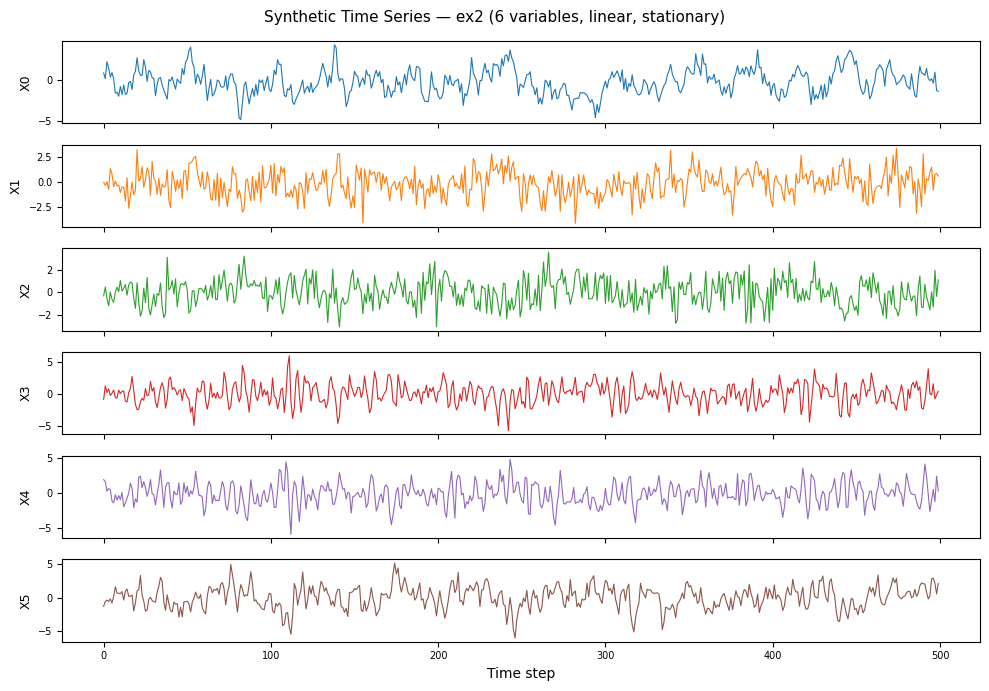

In [10]:
fig, axes = plt.subplots(6, 1, figsize=(10, 7), sharex=True)
for i, col in enumerate(df.columns):
    axes[i].plot(df[col].values, lw=0.8, color=f"C{i}")
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].tick_params(labelsize=7)
axes[-1].set_xlabel("Time step", fontsize=10)
fig.suptitle("Synthetic Time Series — ex2 (6 variables, linear, stationary)", fontsize=11)
plt.tight_layout()
plt.show()

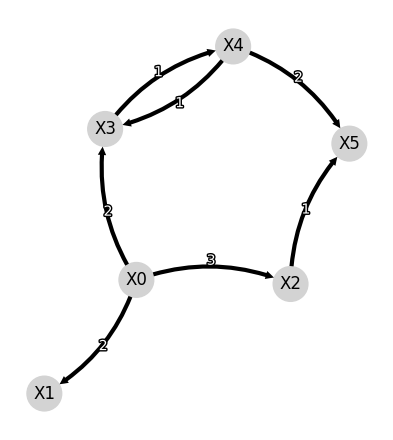

In [11]:
fig, ax = plt.subplots(figsize=(5, 4.5))
plot_graph(gt, var_names=names, fig_ax=(fig, ax),
           title="Ground Truth Graph", show_colorbar=False)
plt.tight_layout()
plt.show()

In [12]:
# Constraint-based: CDNOTS
ci_test   = PartialCorr(data=df.values)
result_cb = run_cdnots(df, indep_test=ci_test, num_lags=max_lag,
                       include_C=False, alpha=0.05,
                       verbose=False, show_progress=False)
G_cb = result_cb.cg_tig
m_cb = evaluate_graph(G_cb, gt)
print(f"CDNOTS (constraint-based):  F1={m_cb['F1']:.3f}  TPR={m_cb['TPR']:.3f}  "
      f"Precision={m_cb['Precision']:.3f}  SHD={m_cb['SHD']}")

# Score-based: GES
G_ges, _ = ges_discovery(df, max_lag=max_lag)
m_ges    = evaluate_graph(G_ges, gt)
print(f"GES      (score-based):     F1={m_ges['F1']:.3f}  TPR={m_ges['TPR']:.3f}  "
      f"Precision={m_ges['Precision']:.3f}  SHD={m_ges['SHD']}")

CDNOTS (constraint-based):  F1=0.762  TPR=0.727  Precision=0.800  SHD=5


GES      (score-based):     F1=0.917  TPR=1.000  Precision=0.846  SHD=2


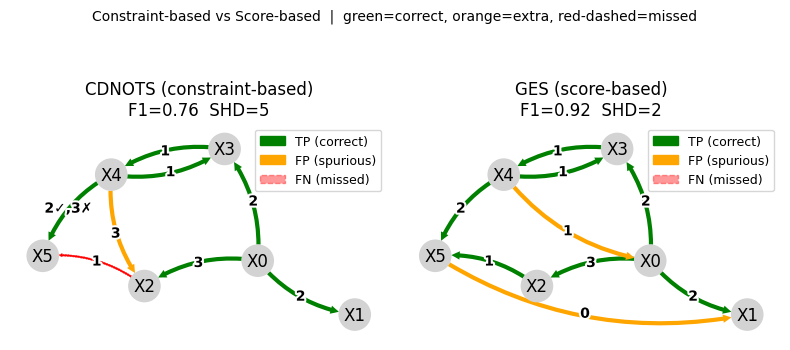

In [13]:
# Colour-coded comparison: green=TP, orange=FP, red-dashed=FN
# Reuse the first panel's node layout for the second so the two graphs are
# directly comparable -- otherwise each panel lays its nodes out independently
# and the same variable sits in a different place on each side.
fig, axes = plt.subplots(1, 2, figsize=(8, 4.0))
_, _, node_pos = compare_graphs(
    gt, G_cb, var_names=names, fig_ax=(fig, axes[0]),
    title=f"CDNOTS (constraint-based)\nF1={m_cb['F1']:.2f}  SHD={m_cb['SHD']}",
    legend_loc="best", return_pos=True)
compare_graphs(gt, G_ges, var_names=names, fig_ax=(fig, axes[1]),
               title=f"GES (score-based)\nF1={m_ges['F1']:.2f}  SHD={m_ges['SHD']}",
               legend_loc="best", node_pos=node_pos)
plt.suptitle("Constraint-based vs Score-based  |  green=correct, orange=extra, red-dashed=missed",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

**What just happened?** On this dataset the score-based method comes out ahead:
GES recovers every true edge (TPR 1.00, SHD 2) while CDNOTS misses a few (TPR 0.73,
SHD 5). Don't over-read that — `ex2` is linear, Gaussian, stationary and small, which
is exactly where a BIC score is at its strongest. The table below says when each family
is the safer default; Part 5 shows a case where the constraint-based approach is the
one that holds up.

### Reading the Metrics

| Metric | Meaning | Perfect |
|---|---|---|
| **TPR** | Fraction of real edges found | 1.0 |
| **Precision** | Fraction of found edges that are real | 1.0 |
| **F1** | Harmonic mean of TPR and Precision | 1.0 |
| **SHD** | Edits needed to reach ground truth | 0 |

### When to use which?

| Situation | Recommended |
|---|---|
| Linear, Gaussian, small graphs | Either (GES is often faster) |
| Nonlinear dependencies | Constraint-based + kernel CI test (SplitKCI) |
| Large graphs (d > 20) | CEDAR (constraint-based, O(d²) pairwise) |
| Need p-values | Constraint-based |
| Avoid multiple testing | Score-based |

---

## Part 5 — Nonstationarity: When the DGP Changes Over Time

Classical discovery assumes **stationarity** — the causal relationships are constant over time. This fails whenever variables share a trend (population growth, inflation, macro regimes). Algorithms that ignore trends will link all trending variables with spurious edges.

Below: 7 variables where only `Temp → Energy` is real. The rest are all driven upward by the same hidden trend — yet they all look correlated.

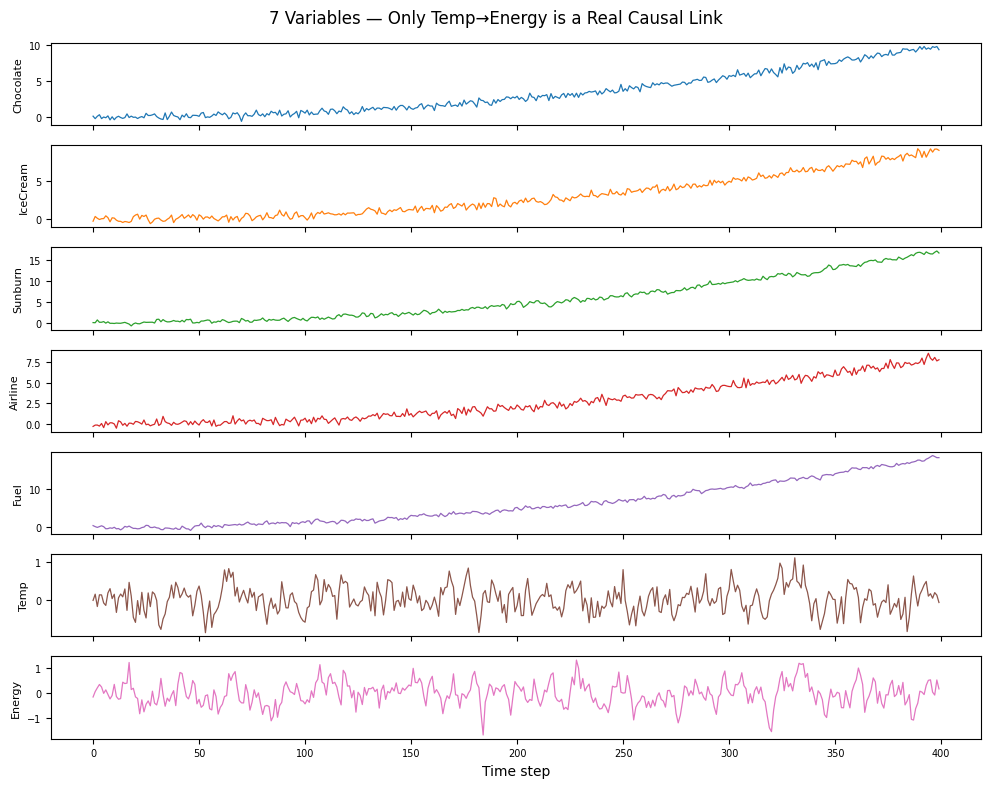

In [14]:
ct    = confounded_trends(seed=42, T=400)
df_ct = ct["df"]

fig, axes = plt.subplots(7, 1, figsize=(10, 8), sharex=True)
for i, col in enumerate(df_ct.columns):
    axes[i].plot(df_ct[col].values, lw=0.9, color=f"C{i}")
    axes[i].set_ylabel(col, fontsize=8)
    axes[i].tick_params(labelsize=7)
axes[-1].set_xlabel("Time step", fontsize=10)
fig.suptitle("7 Variables — Only Temp→Energy is a Real Causal Link", fontsize=12)
plt.tight_layout()
plt.show()

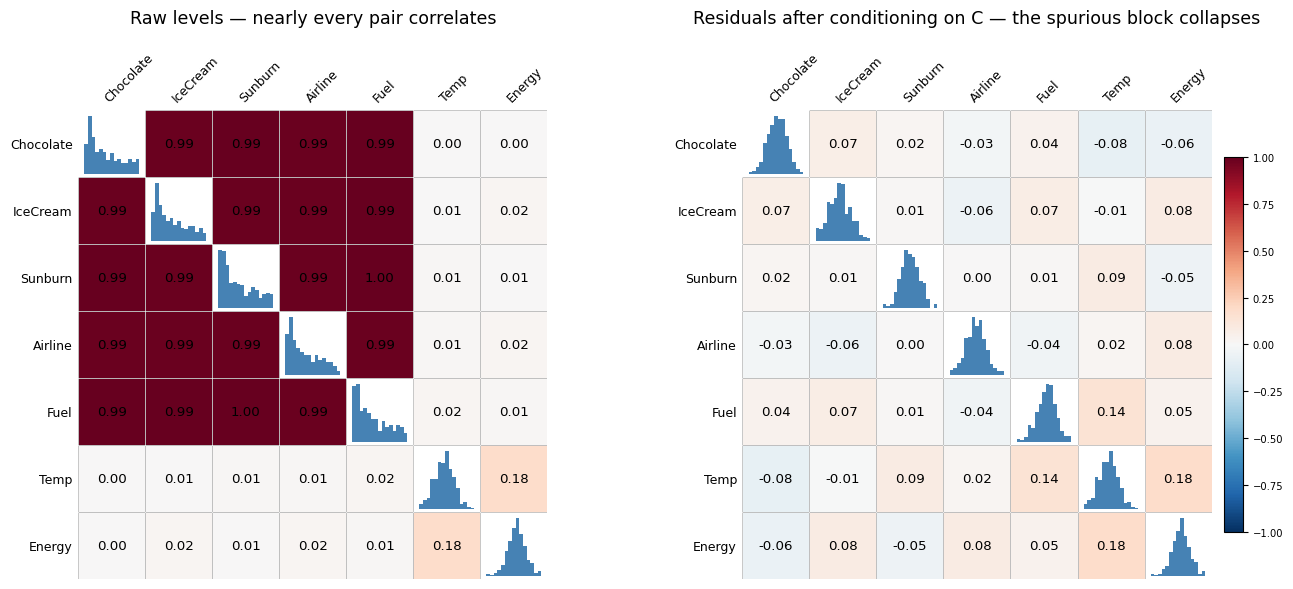

Mean |r| over all 21 pairs:  raw 0.49  ->  conditioned on C 0.06
Pairs above |r| = 0.8:       raw 10  ->  conditioned on C 0
Temp-Energy, same time step: r = 0.18   (strongest pair left, but weak)
Temp(t-2) -> Energy(t):      r = 0.66   <- the real edge, only visible at the right lag


In [15]:
# Condition on the same time-index node C that CDNOTS builds internally.
# confounded_trends injects a quadratic trend, so "linear+quad" is the matching basis.
T_ct     = len(df_ct)
C_basis  = make_c_array(T_ct, preset="linear+quad")
design   = np.column_stack([np.ones(T_ct), C_basis])
coef, *_ = np.linalg.lstsq(design, df_ct.values, rcond=None)
df_resid = pd.DataFrame(df_ct.values - design @ coef, columns=df_ct.columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
corrplot(df_ct, method="color", is_corr=True, add_coef=True, number_cex=1.2,
         tl_cex=0.9, cl_pos="n", fig_ax=(fig, axes[0]),
         title="Raw levels — nearly every pair correlates")
corrplot(df_resid, method="color", is_corr=True, add_coef=True, number_cex=1.2,
         tl_cex=0.9, fig_ax=(fig, axes[1]),
         title="Residuals after conditioning on C — the spurious block collapses")
plt.tight_layout()
plt.show()

iu      = np.triu_indices(df_ct.shape[1], 1)
raw_off = np.abs(df_ct.corr().values[iu])
res     = df_resid.corr()
res_off = np.abs(res.values[iu])
t, e    = df_resid["Temp"].values, df_resid["Energy"].values

print(f"Mean |r| over all {len(raw_off)} pairs:  raw {raw_off.mean():.2f}  ->  conditioned on C {res_off.mean():.2f}")
print(f"Pairs above |r| = 0.8:       raw {int((raw_off > 0.8).sum())}  ->  conditioned on C {int((res_off > 0.8).sum())}")
print(f"Temp-Energy, same time step: r = {res.loc['Temp', 'Energy']:.2f}   (strongest pair left, but weak)")
print(f"Temp(t-2) -> Energy(t):      r = {np.corrcoef(t[:-2], e[2:])[0, 1]:.2f}   <- the real edge, only visible at the right lag")


### The Solution: CDNOTS and the C Node

Two things to read off the figure above. The left panel is what a naive analysis sees: a solid block of correlations near 0.99 between five variables that have nothing to do with each other. Remove the shared trend and that block collapses to noise. The diagonal tells the same story: corrplot draws the marginal distribution of whatever it is given, and the right panel is not the raw series but the **residuals** left after regressing each variable on C. Raw `Chocolate` is a quadratic ramp, so its marginal is skewed and stretched; strip the trend and what remains is the innovation noise, symmetric and tight.

The second thing is a warning. Even after conditioning, `Temp`–`Energy` reaches only **r = 0.18** at the same time step — barely ahead of `Fuel`–`Temp` at 0.14, which is pure noise. A correlation matrix compares variables at one instant, and the real mechanism here is `Temp(t-2) → Energy(t)`; look at the right lag and the same pair reaches **0.66**. Removing the confound is necessary but not sufficient: you also have to search over lags.

`causal-ts` does both. It handles nonstationarity by adding a synthetic **time-index node C** to the graph — the same basis we just regressed out by hand. Variables driven by a trend get an edge from C, and once the algorithm conditions on C the spurious correlations vanish. Lags it searches directly.


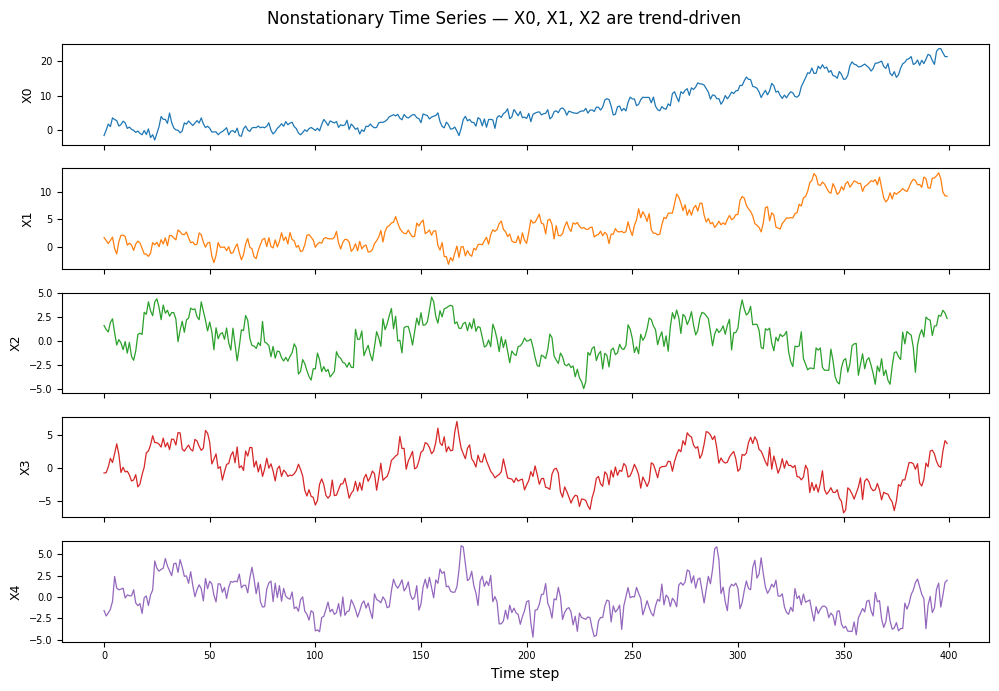

In [16]:
ns       = ex1_nonstationary(seed=32, T=400)
df_ns    = ns["df"]
gt_ns    = ns["ground_truth"]
names_ns = ns["var_names"]
max_lag_ns = ns["max_lag"]

fig, axes = plt.subplots(5, 1, figsize=(10, 7), sharex=True)
for i, col in enumerate(df_ns.columns):
    axes[i].plot(df_ns[col].values, lw=0.9, color=f"C{i}")
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].tick_params(labelsize=7)
axes[-1].set_xlabel("Time step", fontsize=10)
fig.suptitle("Nonstationary Time Series — X0, X1, X2 are trend-driven", fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
ci_ns = PartialCorr(data=df_ns.values)
result_cdnots = run_cdnots(
    df_ns, indep_test=ci_ns,
    num_lags=max_lag_ns, include_C=True, c_preset="linear",
    alpha=0.05, verbose=False, show_progress=False,
)
G_cdnots = result_cdnots.cg_tig
m_cdnots = evaluate_graph(G_cdnots, gt_ns)
print(f"CDNOTS (with C):  F1={m_cdnots['F1']:.3f}  TPR={m_cdnots['TPR']:.3f}  "
      f"Precision={m_cdnots['Precision']:.3f}  SHD={m_cdnots['SHD']}")

CDNOTS (with C):  F1=0.783  TPR=0.818  Precision=0.750  SHD=5


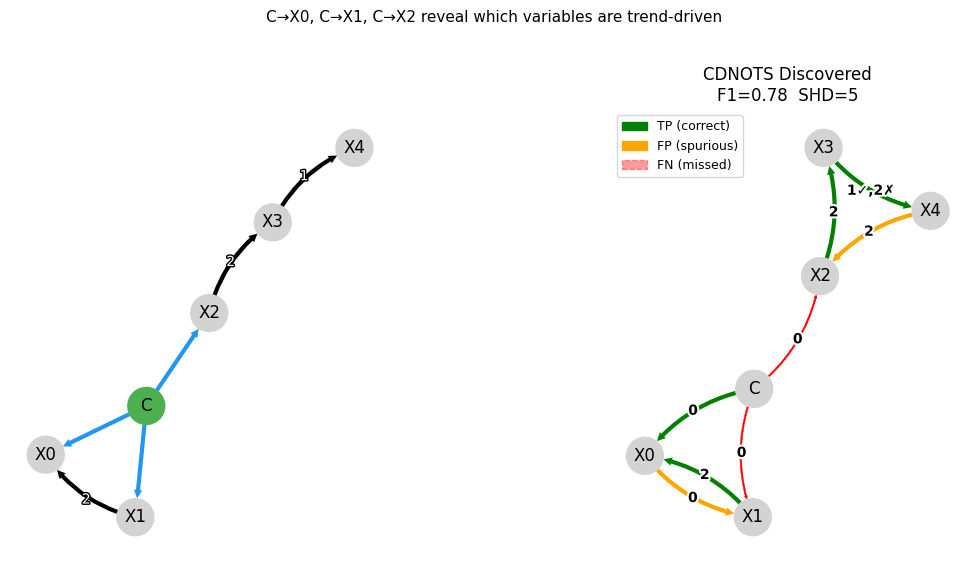

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_graph(gt_ns, var_names=names_ns, fig_ax=(fig, axes[0]), target_node='C',
           title="Ground Truth (with C node)", show_colorbar=False)
compare_graphs(gt_ns, G_cdnots, var_names=names_ns, fig_ax=(fig, axes[1]),legend_loc=None,
               title=f"CDNOTS Discovered\nF1={m_cdnots['F1']:.2f}  SHD={m_cdnots['SHD']}")
plt.suptitle("C→X0, C→X1, C→X2 reveal which variables are trend-driven",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

The edges `C → X0`, `C → X1`, `C → X2` tell us these variables are driven by a time trend — exactly matching the true generating equations. Without the C node, a standard algorithm would place spurious edges between them.

---

## Part 6 — Summary and Next Steps

### Five Key Takeaways

1. **Correlation is not causation.** Two variables can be strongly correlated due to a common cause, selection bias, or a shared trend — not because one causes the other.

2. **Discovery and inference are two steps in a pipeline.** Discover the graph first; then estimate effect sizes on it. A bad graph produces wrong effects.

3. **Discovery requires three assumptions:** Causal Markov, Faithfulness, and Causal Sufficiency. Violations lead to silent errors.

4. **Constraint-based methods** test conditional independences to prune edges; **score-based methods** search for the best-fitting DAG. Both are identifiable from data under the same assumptions.

5. **Nonstationarity creates spurious correlations.** `causal-ts` absorbs trends into a C node, turning a problem into a signal.

---

### Where to Go Next

| Notebook | What you'll learn |
|---|---|
| [`tutorial.ipynb`](../tutorial.ipynb) | All algorithms benchmarked on multiple datasets |
| [`effect_estimation.ipynb`](effect_estimation.ipynb) | Estimating causal effects after discovery (DoWhy) |
| [`ci_test_comparison.ipynb`](ci_test_comparison.ipynb) | Choosing the right CI test (linear vs nonlinear, GPU) |
| [`cedar_deep_dive.ipynb`](cedar_deep_dive.ipynb) | CEDAR internals and lag selection |
| [`cdnots_or_cdnots_plus.ipynb`](cdnots_or_cdnots_plus.ipynb) | CDNOTS vs CDNOTS+ |
| [`plotting.ipynb`](plotting.ipynb) | Full visualisation options |

---

### Quick API Reference

```python
from causalts.synthetic_data.synthetic_datasets import ex2, ex1_nonstationary
from causalts.ci_tests import PartialCorr
from causalts import run_cdnots
from causalts.baselines import ges_discovery
from causalts.plotting import plot_graph, compare_graphs
from causalts.utils import evaluate_graph

ds = ex2(seed=42, T=500)
df, gt, max_lag = ds["df"], ds["ground_truth"], ds["max_lag"]

# Constraint-based
ci = PartialCorr(data=df.values)
result = run_cdnots(df, indep_test=ci, num_lags=max_lag, include_C=False, alpha=0.05)
G_hat = result.cg_tig          # shape (d, d, max_lag+1)

# Score-based
G_ges, _ = ges_discovery(df, max_lag=max_lag)

metrics = evaluate_graph(G_hat, gt)          # F1, TPR, Precision, SHD
plot_graph(G_hat, var_names=list(df.columns))
compare_graphs(gt, G_hat, var_names=list(df.columns))
```